# Configuración básica (no tocar)

In [339]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [340]:
x = Variable()

# Implementación de métodos

In [341]:
# Implementar para hallar raíces de las derivadas, no de f

def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    if df.eval(a) * df.eval(b) >= 0:
        raise ValueError("La función no cambia de signo en el intervalo [a, b]")

    for iteraciones in range(max_iter):
        iteraciones += 1
        xn = (a + b) / 2

        if -tol < df.eval(xn) < tol:  
            return xn, iteraciones
        
        if df.eval(a) * df.eval(xn) < 0:  
            b = xn
        else:  
            a = xn
    return xn, iteraciones

def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    ddf = df.derivative()
    xn = x0

    for iteraciones in range(max_iter):
        fx= df.eval(xn)
        
        if -tol < fx < tol:  
            return xn, iteraciones
        
        dfx = ddf.eval(xn)

        if -tol < dfx < tol:
            raise ZeroDivisionError(
                "Segunda derivada cercana a cero"
            )
        xn = xn - fx / dfx

    return xn, iteraciones
    

def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0
    

    for iteraciones in range(max_iter):
        fx = df.eval(xn)
        
        if -tol < fx < tol:  
            return xn, iteraciones
        
        xn = xn - lr * fx
    return xn, iteraciones


print(biseccion(x**2,-1,1))
print(biseccion((x + 0.5)**3 - x - 0.5,-1,1))
print(biseccion(-cos(x),-1,1))

print(newton(x**2, 1))
print(newton((x + 0.5)**3 - x - 0.5, 1))
print(newton(-cos(x), 1))

print(descenso_gradiente(x**2, 1, lr=1e-2))
print(descenso_gradiente((x + 0.5)**3 - x - 0.5, 1, lr=1e-2))
print(descenso_gradiente(-cos(x), 1, lr=1e-2))

(0.0, 1)
(0.07735013961791992, 22)
(0.0, 1)
(0.0, 1)
(0.07735026919569789, 5)
(np.float64(2.923566201412306e-13), 4)
(4.915281814827202e-07, 719)
(0.07735055352487515, 408)
(np.float64(4.723143234180145e-05), 999)


### Prueba de métodos

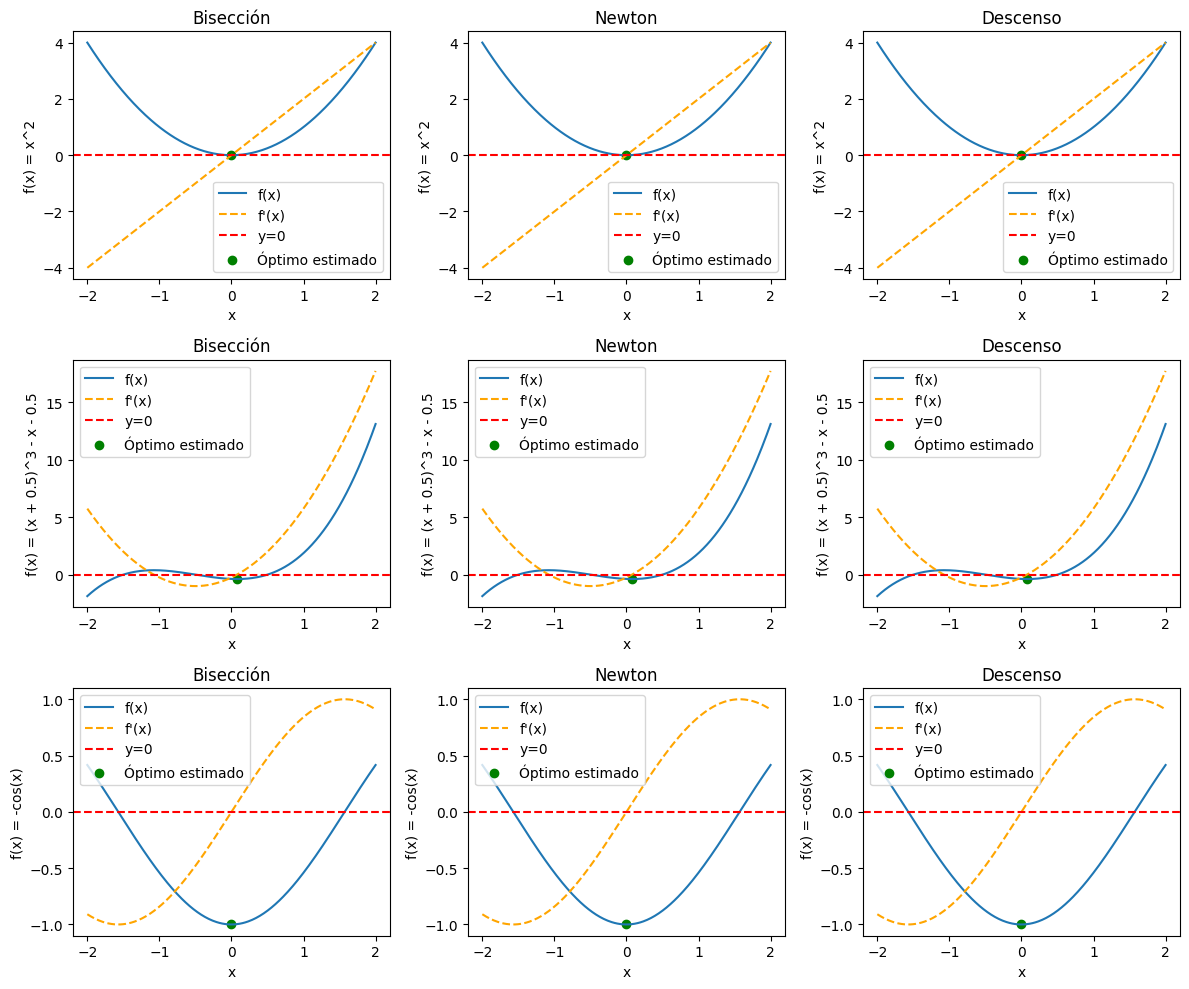

In [342]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step = method(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.show()

# Aplicación a función no trivial

In [343]:
f = x**2 + 2*sin(3*x)

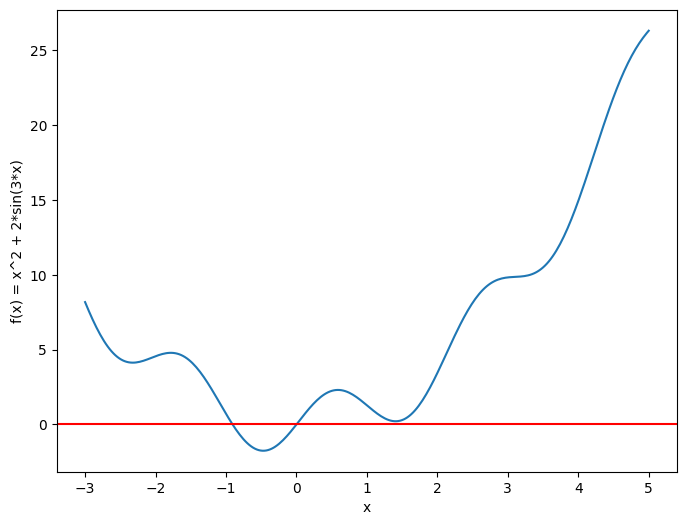

In [344]:
# Grafica de la función

lp = np.linspace(-3, 5, 300)

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_xlabel("x")
ax.set_ylabel("f(x) = x^2 + 2*sin(3*x)")


ax.plot(lp, [f.eval(x) for x in lp])
ax.axhline(0, color="red")
ax.plot()

plt.show()

In [345]:
# Analisis de casos 
casos = []

for a, b in [(-2, 1), (-1, 0), (1, 2)]:
    x, it = biseccion(f, a, b)
    casos.append([
        "Bisección",
        f"[{a}, {b}]",
        "ver análisis",
        x,
        it
    ])

for x0 in [-2, -1, 4]:
    x, it = newton(f, x0)
    casos.append([
        "Newton",
        f"x0={x0}",
        "ver análisis",
        x,
        it
    ])


lr = 0.01
for x0 in [-3, 0.585, 4]:
    x, it = descenso_gradiente(f, x0, lr)
    casos.append([
        "Gradiente",
        f"x0={x0}",
        "ver análisis",
        x,
        it
    ])

tabla = pd.DataFrame(
    casos,
    columns=[
        "Método",
        "Condición inicial",
        "Predicción",
        "Aproximación",
        "Iteraciones"
    ]
)

print(tabla)

      Método Condición inicial    Predicción  Aproximación  Iteraciones
0  Bisección           [-2, 1]  ver análisis     -1.782932           23
1  Bisección           [-1, 0]  ver análisis     -0.471043           24
2  Bisección            [1, 2]  ver análisis      1.407957           21
3     Newton             x0=-2  ver análisis     -1.782932            5
4     Newton             x0=-1  ver análisis      0.589531            4
5     Newton              x0=4  ver análisis      7.820892          999
6  Gradiente             x0=-3  ver análisis     -2.322807          108
7  Gradiente          x0=0.585  ver análisis     -0.471043          109
8  Gradiente              x0=4  ver análisis      1.407957          202


In [346]:
# Analisis de casos con distintos learning rates
casos_distintos_lr = []

for x0 in [-3, 0.585, 4]:
    for lr in [0.001, 0.1, 0.5]:
        x, it = descenso_gradiente(f, x0, lr)
        casos_distintos_lr.append([
            "Gradiente",
            lr,
            f"x0={x0}",
            "ver análisis",
            x,
            it
        ]
    )

tabla = pd.DataFrame(
    casos_distintos_lr,
    columns=[
        "Método",
        "Learning Rate",
        "Condición inicial",
        "Predicción",
        "Aproximación",
        "Iteraciones"
    ]
)

print(tabla)

      Método  Learning Rate Condición inicial    Predicción  Aproximación  \
0  Gradiente          0.001             x0=-3  ver análisis     -2.322808   
1  Gradiente          0.100             x0=-3  ver análisis     -2.322807   
2  Gradiente          0.500             x0=-3  ver análisis     -2.375674   
3  Gradiente          0.001          x0=0.585  ver análisis     -0.471042   
4  Gradiente          0.100          x0=0.585  ver análisis     -0.471043   
5  Gradiente          0.500          x0=0.585  ver análisis      0.845561   
6  Gradiente          0.001              x0=4  ver análisis      2.930800   
7  Gradiente          0.100              x0=4  ver análisis      1.407957   
8  Gradiente          0.500              x0=4  ver análisis     -0.718092   

   Iteraciones  
0          999  
1           17  
2          999  
3          999  
4          612  
5          999  
6          999  
7           63  
8          999  


In [347]:
#Aplicación a función no trivial (Bonus)

def biseccion_sucecion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    if df.eval(a) * df.eval(b) >= 0:
        raise ValueError("La función no cambia de signo en el intervalo [a, b]")

    historial = []

    for iteraciones in range(max_iter):
        xn = (a + b) / 2
        historial.append(xn)
        
        if -tol < df.eval(xn) < tol:  
            return xn, iteraciones, historial
        
        if df.eval(a) * df.eval(xn) < 0:  
            b = xn
        else:  
            a = xn

    return xn, iteraciones, historial

def newton_sucecion(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    ddf = df.derivative()
    xn = x0

    historial = []
    historial.append(xn)

    for iteraciones in range(max_iter):
        fx= df.eval(xn)
        
        if -tol < fx < tol:  
            return xn, iteraciones, historial
        
        dfx = ddf.eval(xn)

        if -tol < dfx < tol:
            raise ZeroDivisionError(
                "Segunda derivada cercana a cero"
            )
        xn = xn - fx / dfx
        historial.append(xn)

    return xn, iteraciones, historial

def descenso_gradiente_sucecion(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0
    historial = []
    historial.append(xn)

    for iteraciones in range(max_iter):
        fx = df.eval(xn)
        
        if -tol < fx < tol:  
            return xn, iteraciones, historial
        
        xn = xn - lr * fx
        historial.append(xn)
    return xn, iteraciones, historial   

def graficar_evolucion(f, historial, titulo):

    xs = np.linspace(-3, 5, 500)

    plt.figure(figsize=(8,6))

    plt.plot(
        xs,
        [f.eval(x) for x in xs],
        label="f(x)"
    )

    plt.scatter(
        historial,
        [f.eval(x) for x in historial],
        c=np.arange(len(historial)),
        cmap="viridis",
        s=60
    )

    plt.colorbar(label="Iteración")

    plt.title(titulo)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True)

    plt.show()


# Ajuste de datos

In [348]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()


In [351]:
# Genere la función de pérdida
def funcion_perdida(modelo, df):
    x_data = df["x"].values
    y_data = df["y"].values

    N = len(x_data)
    perdida = 0

    for i in range(N):
        xi = x_data[i]
        yi = y_data[i]
        prediccion = modelo(xi, w)
        error = prediccion - yi
        perdida = perdida + (error ** 2)

    return perdida/N

def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0

    for iteraciones in range(max_iter):
        fx = df.eval(xn)
        
        if -tol < fx < tol:  
            return xn
                
        xn = xn - lr * fx
    return xn 

def modelo_lineal(x, w):
    return w * x

def modelo_exp(x, w):
    return exp(w * x)

def modelo_sin(x, w):
    return sin(w * x)


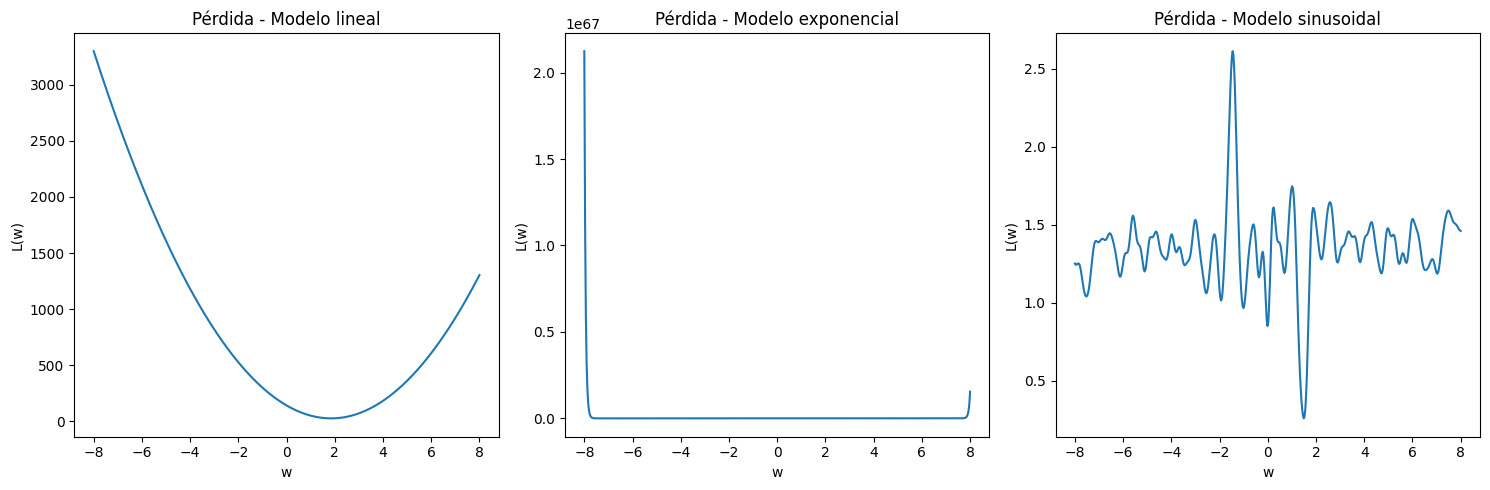

In [352]:
L_linear = funcion_perdida(modelo_lineal, df_linear)
L_exp = funcion_perdida(modelo_exp, df_exp)
L_sin = funcion_perdida(modelo_sin, df_sin)

w_values = np.linspace(-8, 8, 500)

losses = [L_linear, L_exp, L_sin]

titles = [
    "Pérdida - Modelo lineal",
    "Pérdida - Modelo exponencial",
    "Pérdida - Modelo sinusoidal"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, L in enumerate(losses):

    ax = axes[i]

    y = [L.eval(w) for w in w_values]

    ax.plot(w_values, y)

    ax.set_xlabel("w")
    ax.set_ylabel("L(w)")
    ax.set_title(titles[i])

plt.tight_layout()
plt.show()

In [ ]:
#Obtener el w óptimo para algún learning rate
L_linear = funcion_perdida(modelo_lineal, df_linear)
L_exp = funcion_perdida(modelo_exp, df_exp)
L_sin = funcion_perdida(modelo_sin, df_sin)

w_opt_linear = descenso_gradiente(L_linear, x0 = 0, lr=0.001)
w_opt_exp = descenso_gradiente(L_exp, x0 = 0, lr=0.001)
w_opt_sin = descenso_gradiente(L_sin, x0 = 0, lr=0.001)

print(w_opt_linear)
print(w_opt_exp)
print(w_opt_sin)


1.8479936159266037
0.21257607800858003
0.1858211584345344


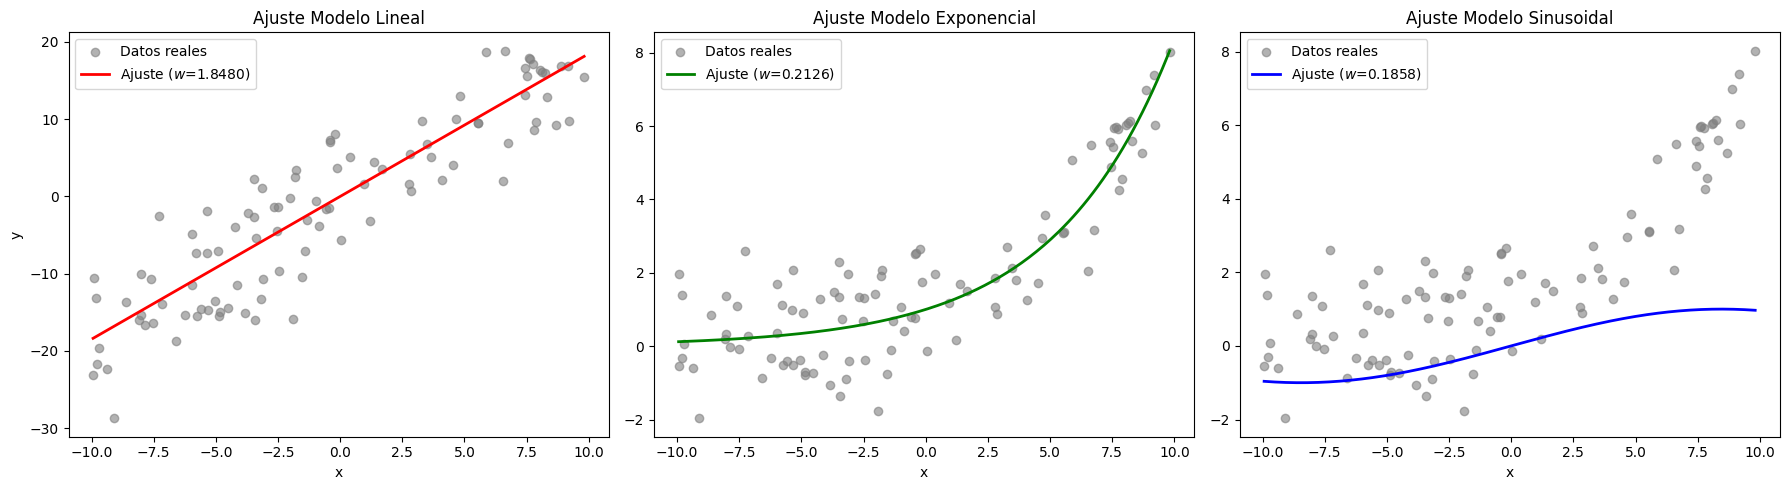

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(df_linear["x"], df_linear["y"], color="gray", alpha=0.6, label="Datos reales")
x_plot = np.linspace(df_linear["x"].min(), df_linear["x"].max(), 200)
y_plot = modelo_lineal(x_plot, w_opt_linear) 
ax.plot(x_plot, y_plot, color="red", linewidth=2, label=f"Ajuste ($w$={w_opt_linear:.4f})")
ax.set_title("Ajuste Modelo Lineal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()


ax = axes[1]
ax.scatter(df_exp["x"], df_exp["y"], color="gray", alpha=0.6, label="Datos reales")
x_plot = np.linspace(df_exp["x"].min(), df_exp["x"].max(), 200)
y_plot = np.exp(w_opt_exp * x_plot) 
ax.plot(x_plot, y_plot, color="green", linewidth=2, label=f"Ajuste ($w$={w_opt_exp:.4f})")
ax.set_title("Ajuste Modelo Exponencial")
ax.set_xlabel("x")
ax.legend()

ax = axes[2]
ax.scatter(df_sin["x"], df_sin["y"], color="gray", alpha=0.6, label="Datos reales")
x_plot = np.linspace(df_sin["x"].min(), df_sin["x"].max(), 500) 
y_plot = np.sin(w_opt_sin * x_plot) 
ax.plot(x_plot, y_plot, color="blue", linewidth=2, label=f"Ajuste ($w$={w_opt_sin:.4f})")
ax.set_title("Ajuste Modelo Sinusoidal")
ax.set_xlabel("x")
ax.legend()

plt.tight_layout()
plt.show()

# BONUS (5.1)

In [413]:
def modelo_lineal(x, w):
    return w * x

def modelo_exp(x, w):
    return np.exp(w * x)

def modelo_sin(x, w):
    return np.sin(w * x)

def dmodelo_lineal(x, w):
    return x

def dmodelo_exp(x, w):
    return np.exp(w * x) * x

def dmodelo_sin(x, w):
    return np.cos(w * x) * x

def sgd(modelo, dmodelo, df, w0, lr, max_iter=1000):
    x_data = df["x"].values
    y_data = df["y"].values

    wn = w0

    for iteraciones in range(max_iter):
        # Elegir un índice aleatorio
        idx = np.random.randint(0, len(x_data))
        xi = x_data[idx]
        yi = y_data[idx]

        prediccion = modelo(xi, wn)
        error = prediccion - yi

        gradiente = 2 * error * dmodelo(xi, wn) 

        # Actualizar w
        wn = wn - lr * gradiente 

    return wn

L_linear = sgd(modelo_lineal, dmodelo_lineal, df_linear, w0=0, lr=0.0001)
L_exp = sgd(modelo_exp, dmodelo_exp, df_exp, w0=0, lr=0.0001)
L_sin = sgd(modelo_sin, dmodelo_sin, df_sin, w0=0, lr=0.0001)

print(L_linear)
print(L_exp)   
print(L_sin)

1.8236636961148183
0.21172905723391808
-0.010562914401746564


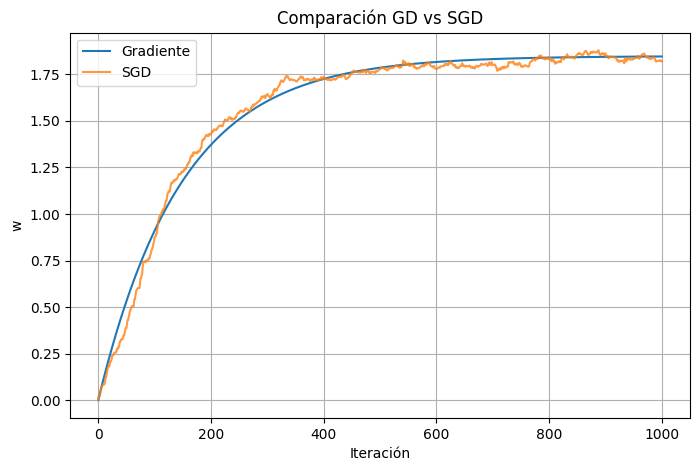

In [429]:
# Comparación de resultados entre descenso de gradiente y SGD

def gd(modelo, dmodelo, df, w0, lr, max_iter=1000):
    x_data = df["x"].values
    y_data = df["y"].values
    wn = w0

    historia = []
    historia.append(wn)

    for iteraciones in range(max_iter):
        prediccion = modelo(x_data, wn)
        error = prediccion - y_data

        gradiente = np.mean(2 * error * dmodelo(x_data, wn)) 

        wn = wn - lr * gradiente 
        historia.append(wn)
    return wn, historia

def sgd(modelo, dmodelo, df, w0, lr, max_iter=1000):
    x_data = df["x"].values
    y_data = df["y"].values

    wn = w0
    historia = []
    historia.append(wn)

    for iteraciones in range(max_iter):
        idx = np.random.randint(0, len(x_data))
        xi = x_data[idx]
        yi = y_data[idx]

        prediccion = modelo(xi, wn)
        error = prediccion - yi

        gradiente = 2 * error * dmodelo(xi, wn) 

        wn = wn - lr * gradiente 
        historia.append(wn)

    return wn, historia

w_gd, hist_gd = gd(modelo_lineal,dmodelo_lineal,df_linear,w0=0,lr=0.0001)
w_sgd, hist_sgd = sgd(modelo_lineal,dmodelo_lineal,df_linear,w0=0,lr=0.0001)

plt.figure(figsize=(8,5))

plt.plot(hist_gd, label="Gradiente")
plt.plot(hist_sgd, label="SGD", alpha=0.8)

plt.xlabel("Iteración")
plt.ylabel("w")
plt.title("Comparación GD vs SGD")
plt.legend()
plt.grid(True)

plt.show()
